In [ ]:
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Análisis Exploratorio de datos


In [ ]:
df_final=pd.read_csv('df_final.csv',encoding='latin-1')


In [ ]:
print(tabulate(df_final.head(),headers='keys',tablefmt='psql'))

+----+----------------------+--------+--------------------------+--------------------------------------------------------+-----------------------------------------------------------------------------------------------------+--------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+----------------+-------------------+------------------+--------------------+----------------+------------------+--------------------+--------+----------+---------+------------------------+-----------------------+-----------+
|    | Comunidad Autonoma   | Sexo   | Pais                     | Estudios                                               | Clase                                                                                               |   Edad |   Carne_frec |   Lacteos_frec |   Pescado_frec |   Fruta_frec |   Embutidos_frec |   Verduras_frec |   Refrescos_frec |   Alcohol_cant | Salud_Percibida   |   Cronicidad_bin |   Hipertens

In [ ]:
print("Dimensiones del conjunto de datos",df_final.shape)

Dimensiones del conjunto de datos (21010, 26)


In [ ]:
print("Tipos de datos del conjunto de datos:\n\n",df_final.dtypes.value_counts())

Tipos de datos del conjunto de datos:

 float64    17
object      8
int64       1
Name: count, dtype: int64


In [ ]:
print(tabulate(df_final.dtypes.to_frame(),headers='keys',tablefmt='psql'))

+----------------------+---------+
|                      | 0       |
|----------------------+---------|
| Comunidad Autonoma   | object  |
| Sexo                 | object  |
| Pais                 | object  |
| Estudios             | object  |
| Clase                | object  |
| Edad                 | int64   |
| Carne_frec           | float64 |
| Lacteos_frec         | float64 |
| Pescado_frec         | float64 |
| Fruta_frec           | float64 |
| Embutidos_frec       | float64 |
| Verduras_frec        | float64 |
| Refrescos_frec       | float64 |
| Alcohol_cant         | float64 |
| Salud_Percibida      | object  |
| Cronicidad_bin       | float64 |
| Hipertension_bin     | float64 |
| Diabetes_bin         | float64 |
| Colesterol_bin       | float64 |
| Comorbilidad_num     | float64 |
| Peso                 | float64 |
| Altura               | float64 |
| IMC                  | float64 |
| Actividad_física_cat | object  |
| Sedentarismo%_horas  | float64 |
| IMC_cat           

In [ ]:
print("Faltantes en el conjunto:\n",df_final.isna().sum().sort_values(ascending=False))

Faltantes en el conjunto:
 Sedentarismo%_horas     1846
IMC                      977
IMC_cat                  977
Peso                     847
Altura                   524
Hipertension_bin         286
Actividad_física_cat     250
Cronicidad_bin           237
Colesterol_bin           223
Diabetes_bin             141
Refrescos_frec           117
Embutidos_frec           111
Pescado_frec             101
Verduras_frec             99
Fruta_frec                95
Carne_frec                93
Lacteos_frec              93
Alcohol_cant              51
Pais                       0
Estudios                   0
Clase                      0
Edad                       0
Comunidad Autonoma         0
Sexo                       0
Salud_Percibida            0
Comorbilidad_num           0
dtype: int64


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21010 entries, 0 to 21009
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Comunidad Autonoma    21010 non-null  object 
 1   Sexo                  21010 non-null  object 
 2   Pais                  21010 non-null  object 
 3   Estudios              21010 non-null  object 
 4   Clase                 21010 non-null  object 
 5   Edad                  21010 non-null  int64  
 6   Carne_frec            20917 non-null  float64
 7   Lacteos_frec          20917 non-null  float64
 8   Pescado_frec          20909 non-null  float64
 9   Fruta_frec            20915 non-null  float64
 10  Embutidos_frec        20899 non-null  float64
 11  Verduras_frec         20911 non-null  float64
 12  Refrescos_frec        20893 non-null  float64
 13  Alcohol_cant          20959 non-null  float64
 14  Salud_Percibida       21010 non-null  object 
 15  Cronicidad_bin     

Se separan variables categoricas de numéricas para verificar su comportamiento

In [ ]:
var_cat=[c for c in df_final if df_final[c].dtype=='object']
var_num=[c for c in df_final if df_final[c].dtype!='object']
var_cat=df_final[var_cat]
var_num=df_final[var_num]

In [ ]:
print(tabulate(var_cat.describe().T,headers='keys',tablefmt='psql'))

+----------------------+---------+----------+-----------------------------------------------------------------------------------------------------+--------+
|                      |   count |   unique | top                                                                                                 |   freq |
|----------------------+---------+----------+-----------------------------------------------------------------------------------------------------+--------|
| Comunidad Autonoma   |   21010 |       19 | Andalucía                                                                                           |   2672 |
| Sexo                 |   21010 |        2 | Mujer                                                                                               |  11341 |
| Pais                 |   21010 |        2 | Nacidos en España                                                                                   |  18375 |
| Estudios             |   21010 |        8 | Estudios uni

In [ ]:
print(tabulate(var_num.describe().T,headers='keys',tablefmt='psql'))

+---------------------+---------+-------------+-----------+----------+--------+----------+----------+----------+
|                     |   count |        mean |       std |      min |    25% |      50% |      75% |      max |
|---------------------+---------+-------------+-----------+----------+--------+----------+----------+----------|
| Edad                |   21010 |  54.4896    | 19.1419   |  15      |  40    |  55      |  69      | 103      |
| Carne_frec          |   20917 |   3.83896   |  2.55344  |   0      |   1.5  |   3      |   5      |  10      |
| Lacteos_frec        |   20917 |   7.8965    |  3.24428  |   0      |   5    |  10      |  10      |  10      |
| Pescado_frec        |   20909 |   2.15429   |  1.59057  |   0      |   1.5  |   1.5    |   3      |  10      |
| Fruta_frec          |   20915 |   7.0076    |  3.5321   |   0      |   3    |  10      |  10      |  10      |
| Embutidos_frec      |   20899 |   2.6163    |  2.51432  |   0      |   0.5  |   1.5    |   3  

Se puede ver que todas las variables escogidas para el estudio estan dentro del los rangos que se especificaron en la limpieza de los datos.

# Analisis Univariante

**Salud percibida_cat**

In [ ]:
print(tabulate(df_final["Salud_Percibida"].value_counts(normalize=True).to_frame(),headers='keys',tablefmt='psql'))

+-------------------+--------------+
| Salud_Percibida   |   proportion |
|-------------------+--------------|
| Bueno             |    0.485245  |
| Regular           |    0.241409  |
| Muy bueno         |    0.185531  |
| Malo              |    0.0701571 |
| Muy malo          |    0.0176583 |
+-------------------+--------------+


Text(0.5, 1.0, 'Distribución de Salud percibida')

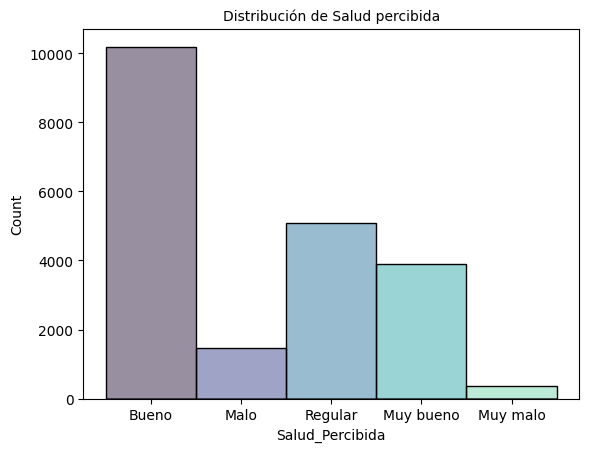

In [ ]:
sns.histplot(data=df_final, x='Salud_Percibida', palette='mako', hue= 'Salud_Percibida',legend=False)
plt.title('Distribución de Salud percibida', fontsize=10)

**Variables de consumo: Alimentos y Alcohol**



In [ ]:
# Variables de consumo (frecuencia y alcohol)

var_frecuencia= [c for c in df_final if "_frec" in c]
var_alcohol= [c for c in df_final if "alcohol" in c.lower()]
var_consumo= df_final[var_frecuencia+ var_alcohol]
print(var_consumo.columns)

Index(['Carne_frec', 'Lacteos_frec', 'Pescado_frec', 'Fruta_frec',
       'Embutidos_frec', 'Verduras_frec', 'Refrescos_frec', 'Alcohol_cant'],
      dtype='object')


In [ ]:
var_frec_plots= df_final[var_frecuencia]

**Consumo de alimentos**

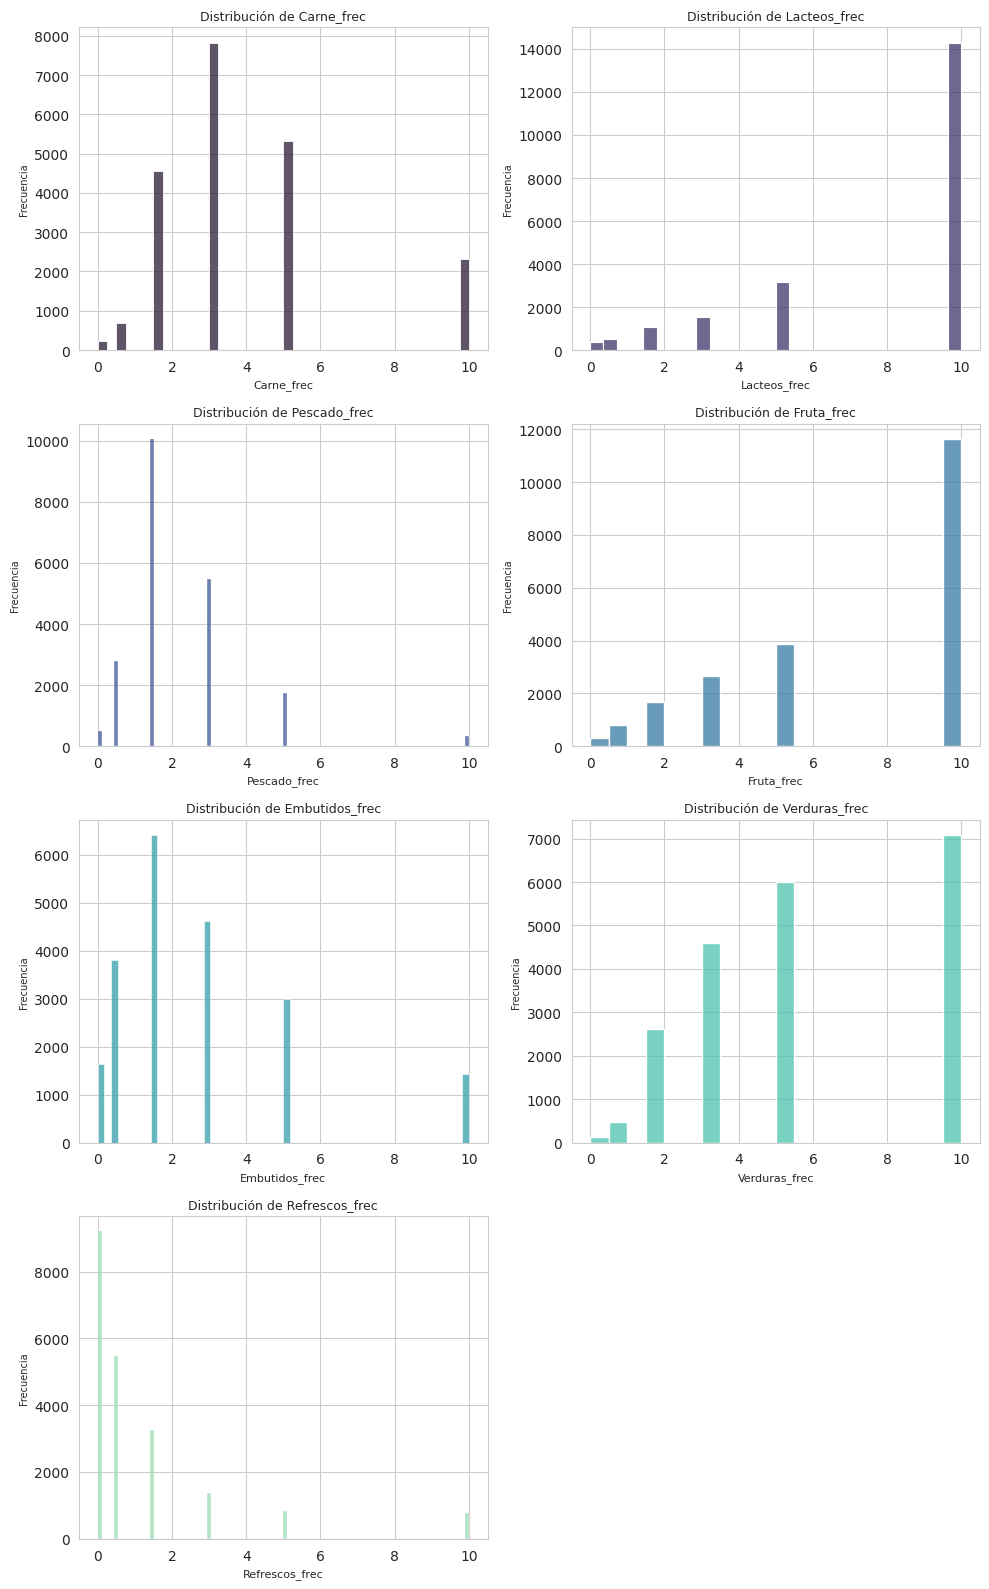

In [ ]:
sns.set_style('whitegrid')
num_columnas= len(var_frec_plots.columns)
cols_grid=2
num_filas= 4

plt.figure(figsize=(cols_grid*5,num_filas*4))

colores= sns.color_palette('mako',num_columnas)

for i, col in enumerate(var_frec_plots):

  plt.subplot(num_filas,cols_grid,i+1)
  sns.histplot(x= df_final [col], kde=False, color= colores[i])
  plt.title(f'Distribución de {col}', fontsize=9)
  plt.xlabel(f'{col}', fontsize=8)
  plt.ylabel('Frecuencia', fontsize=7)
plt.tight_layout()
plt.show()

**Consumo de alcohol**

Text(0, 0.5, 'Frecuencia')

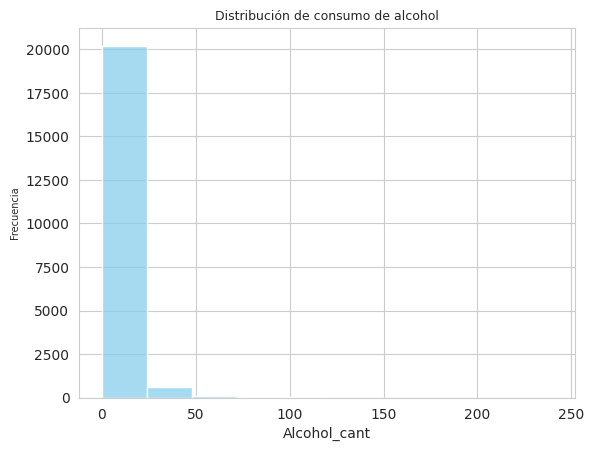

In [ ]:
sns.histplot(data=df_final, x='Alcohol_cant', bins=10, color='skyblue')
plt.title('Distribución de consumo de alcohol', fontsize=9)
plt.ylabel('Frecuencia', fontsize=7)

**Enfermedades y comorbilidad**

In [ ]:
var_enf= [c for c in df_final if "_bin" in c]
var_comorb= [c for c in df_final if "comorbilidad" in c.lower()]
var_enfermedad= df_final[var_enf+ var_comorb]
print(var_enfermedad.columns)

Index(['Cronicidad_bin', 'Hipertension_bin', 'Diabetes_bin', 'Colesterol_bin',
       'Comorbilidad_num'],
      dtype='object')


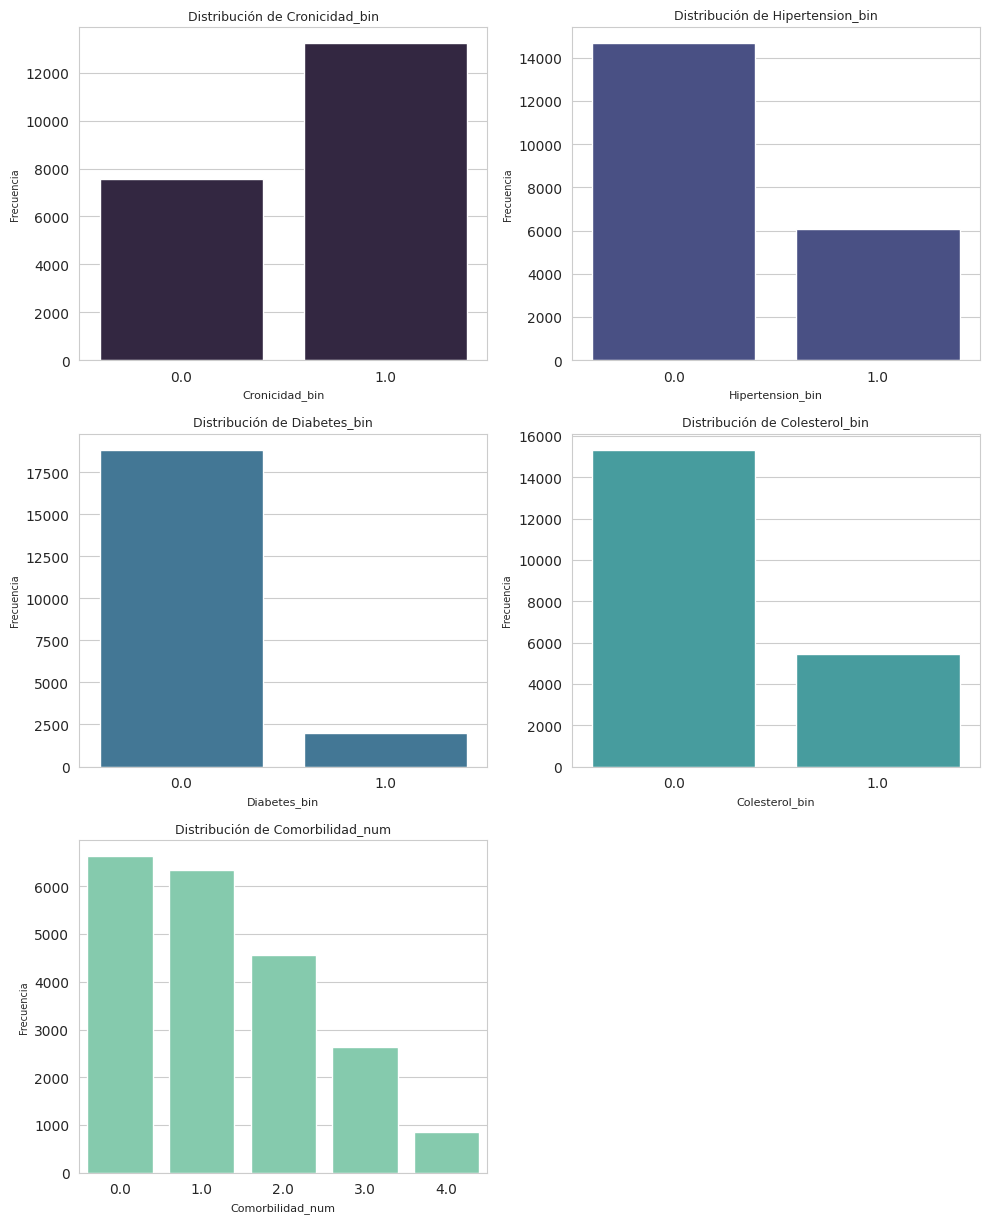

In [ ]:
sns.set_style('whitegrid')
num_columnas= len(var_enfermedad.columns)
cols_grid=2
num_filas= 4

plt.figure(figsize=(cols_grid*5,num_filas*4))

colores= sns.color_palette('mako',num_columnas)

for i, col in enumerate(var_enfermedad):

  plt.subplot(num_filas,cols_grid,i+1)
  sns.countplot(x= df_final [col], color= colores[i])
  plt.title(f'Distribución de {col}', fontsize=9)
  plt.xlabel(f'{col}', fontsize=8)
  plt.ylabel('Frecuencia', fontsize=7)
plt.tight_layout()
plt.show()

**Variables de estilo de vida**

Text(0.5, 0, 'No. horas sentados')

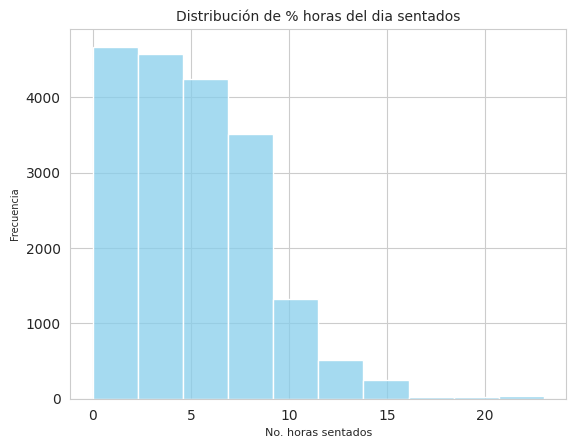

In [ ]:
sns.histplot(data=df_final, x='Sedentarismo%_horas', bins=10, color='skyblue')
plt.title('Distribución de % horas del dia sentados', fontsize=10)
plt.ylabel('Frecuencia', fontsize=7)
plt.xlabel('No. horas sentados', fontsize=8)

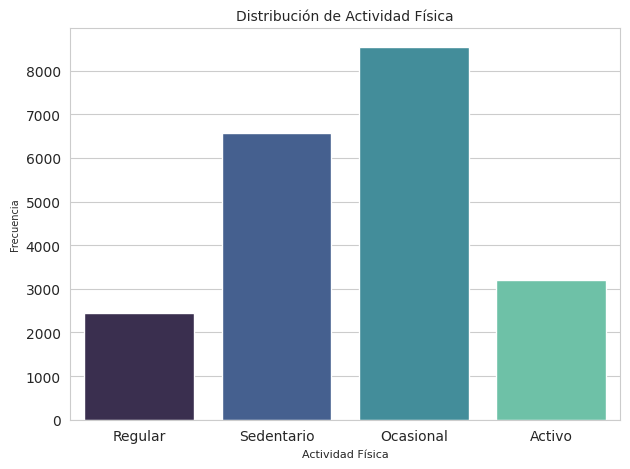

In [ ]:
sns.countplot(data=df_final, x='Actividad_física_cat', palette='mako', hue='Actividad_física_cat',legend=False)
plt.title('Distribución de Actividad Física', fontsize=10)
plt.xlabel('Actividad Física', fontsize=8)
plt.ylabel('Frecuencia', fontsize=7)
plt.tight_layout()

**Varibles estado corporal**

In [ ]:
var_corp=['Peso', 'Altura', 'IMC']
var_corp= df_final[var_corp]

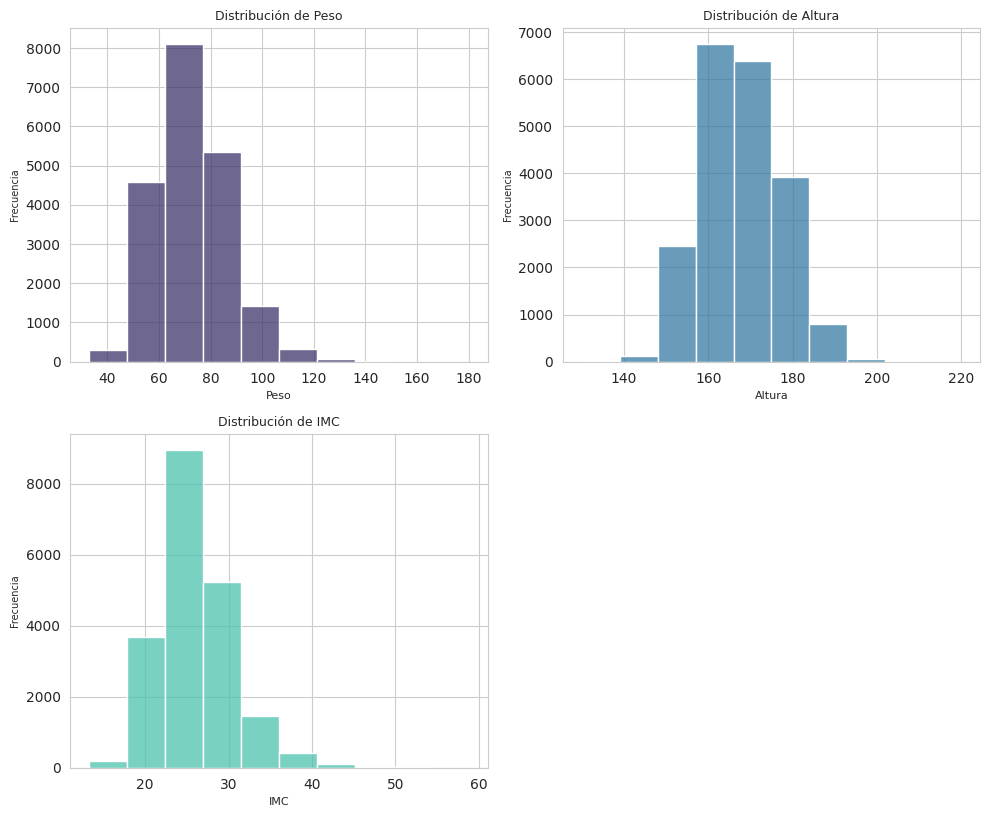

In [ ]:
sns.set_style('whitegrid')
num_columnas= len(var_corp.columns)
cols_grid=2
num_filas= 4

plt.figure(figsize=(cols_grid*5,num_filas*4))

colores= sns.color_palette('mako',num_columnas)

for i, col in enumerate(var_corp):

  plt.subplot(num_filas,cols_grid,i+1)
  sns.histplot(x= df_final [col], kde=False, color= colores[i],bins=10)
  plt.title(f'Distribución de {col}', fontsize=9)
  plt.xlabel(f'{col}', fontsize=8)
  plt.ylabel('Frecuencia', fontsize=7)
plt.tight_layout()
plt.show()

**Variables sociodemográficas**

In [ ]:
var_soc= df_final[['Pais','Sexo']]

In [ ]:
soc1= df_final[['Comunidad Autonoma','Estudios']]

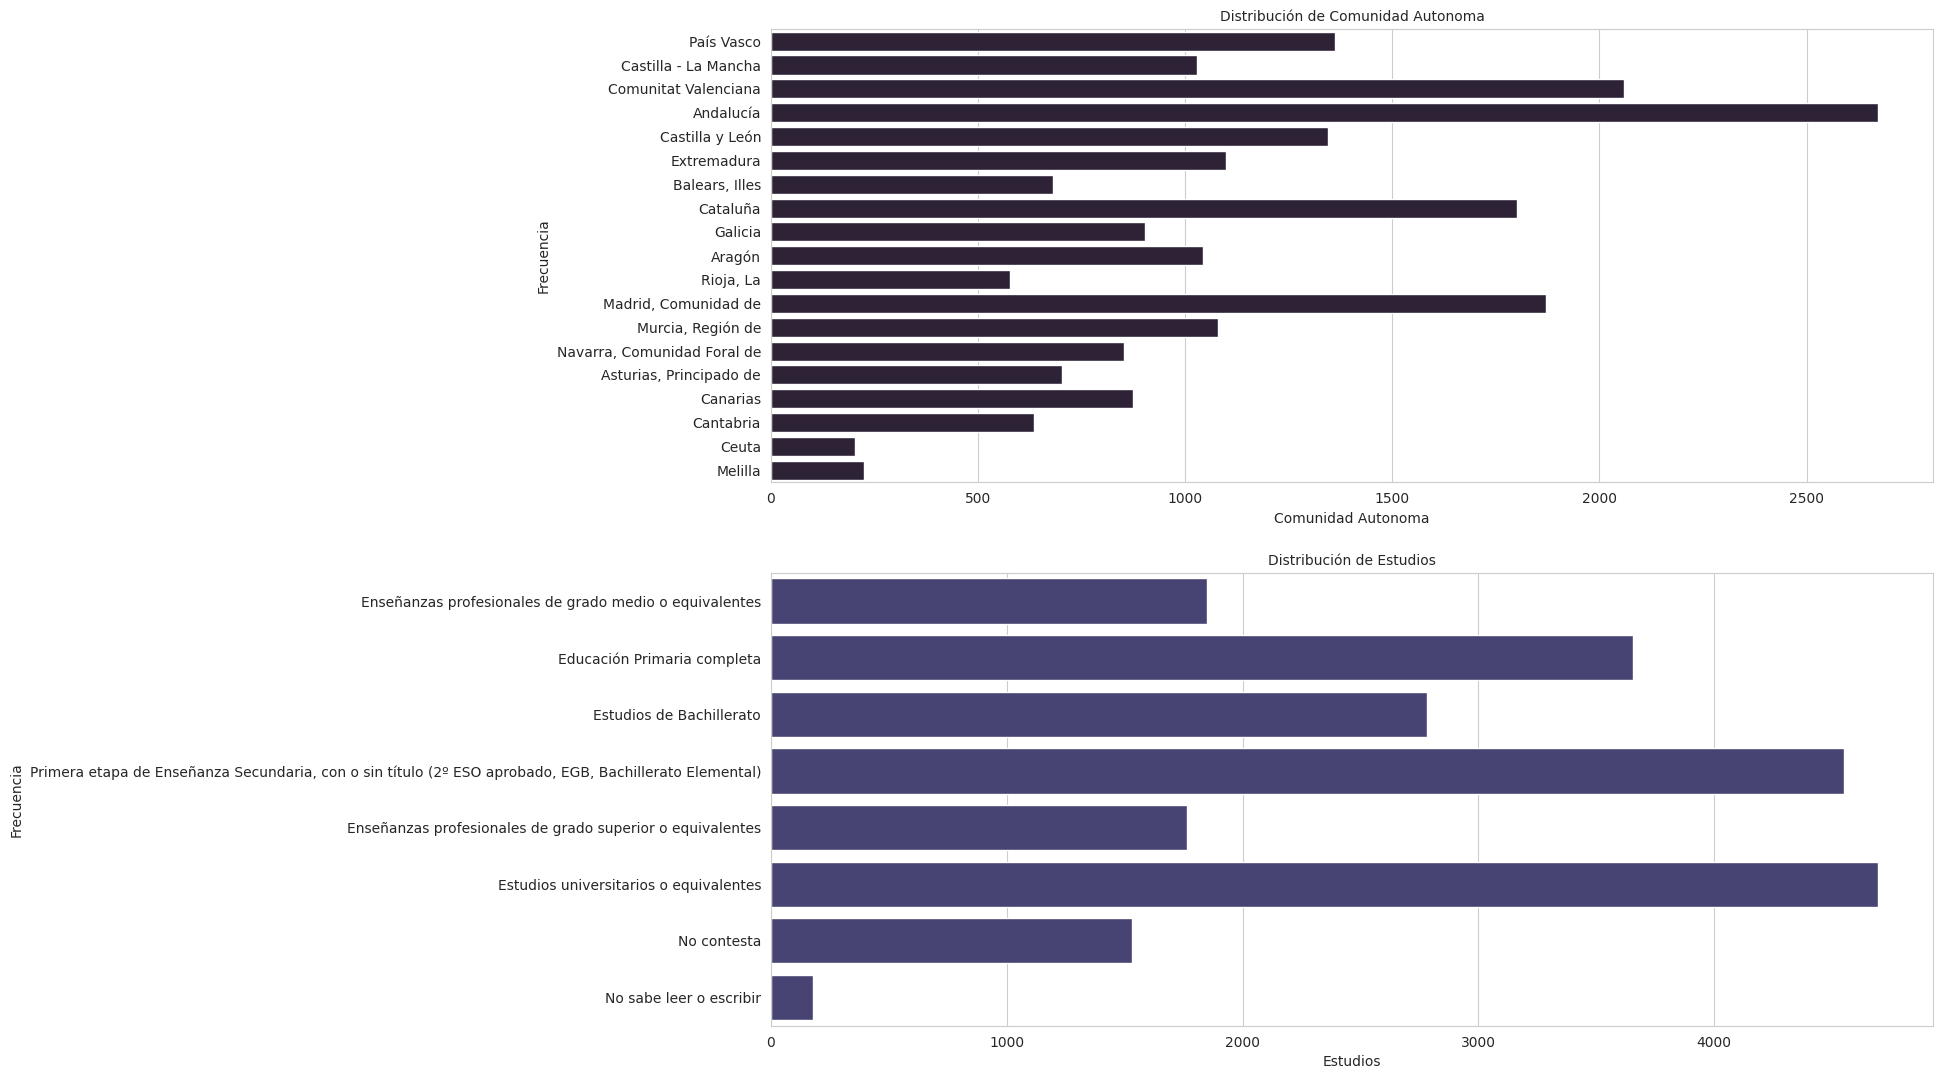

In [ ]:
plt.figure(figsize=(15,20))

colores= sns.color_palette('mako',6)

for i, col in enumerate(soc1):

  plt.subplot(3,1,i+1)
  sns.countplot(y= soc1 [col], color= colores[i])
  plt.title(f'Distribución de {col}', fontsize=10)
  plt.xlabel(f'{col}', fontsize=10,)
  plt.ylabel('Frecuencia', fontsize=10)

plt.show()

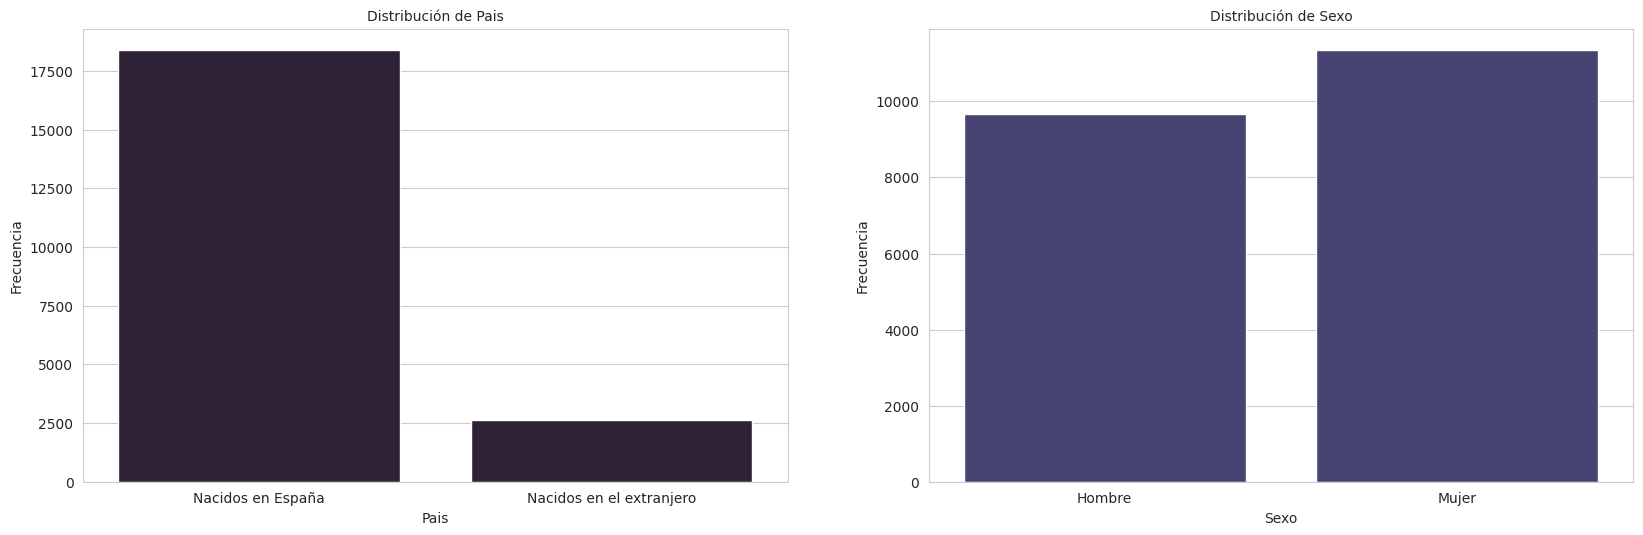

In [ ]:
plt.figure(figsize=(20,20))

colores= sns.color_palette('mako',6)

for i, col in enumerate(var_soc):

  plt.subplot(3,2,i+1)
  sns.countplot(x= var_soc [col], color= colores[i])
  plt.title(f'Distribución de {col}', fontsize=10)
  plt.xlabel(f'{col}', fontsize=10,)
  plt.ylabel('Frecuencia', fontsize=10)

plt.show()

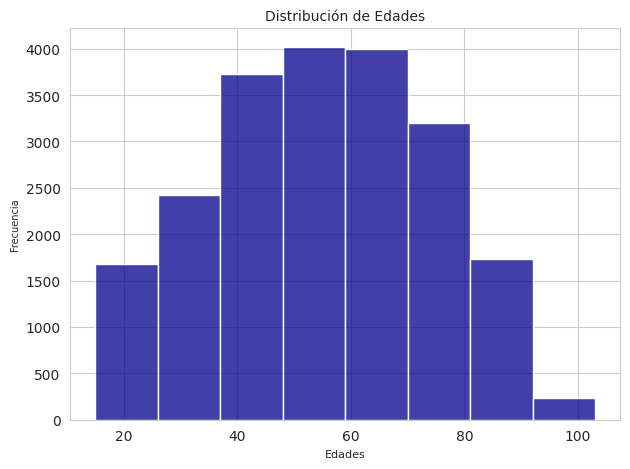

In [ ]:
sns.histplot(data=df_final, x='Edad', bins=8, color="darkblue")
plt.title('Distribución de Edades', fontsize=10)
plt.xlabel('Edades', fontsize=8)
plt.ylabel('Frecuencia', fontsize=7)
plt.tight_layout()
plt.show()

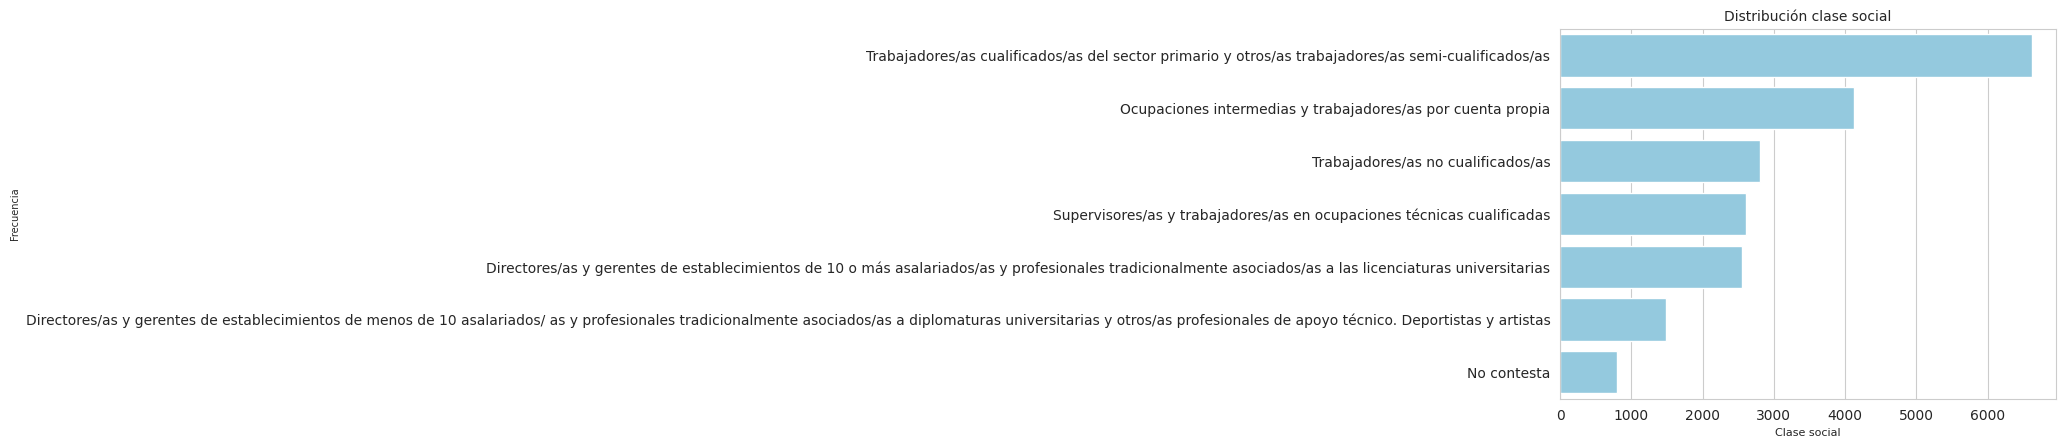

In [ ]:
sns.countplot(data=df_final, y='Clase', color="skyblue",order=df_final['Clase'].value_counts().index)
plt.title('Distribución clase social', fontsize=10)
plt.xlabel('Clase social', fontsize=8)
plt.ylabel('Frecuencia', fontsize=7)
plt.show()

In [ ]:
# Como hay columnas con la etiqueta bin que son booleanas, se crea un subconjunto solo con las que no lo son
boxplot_cols = var_num.loc[:, [col for col in var_num.columns if '_bin' not in col]]


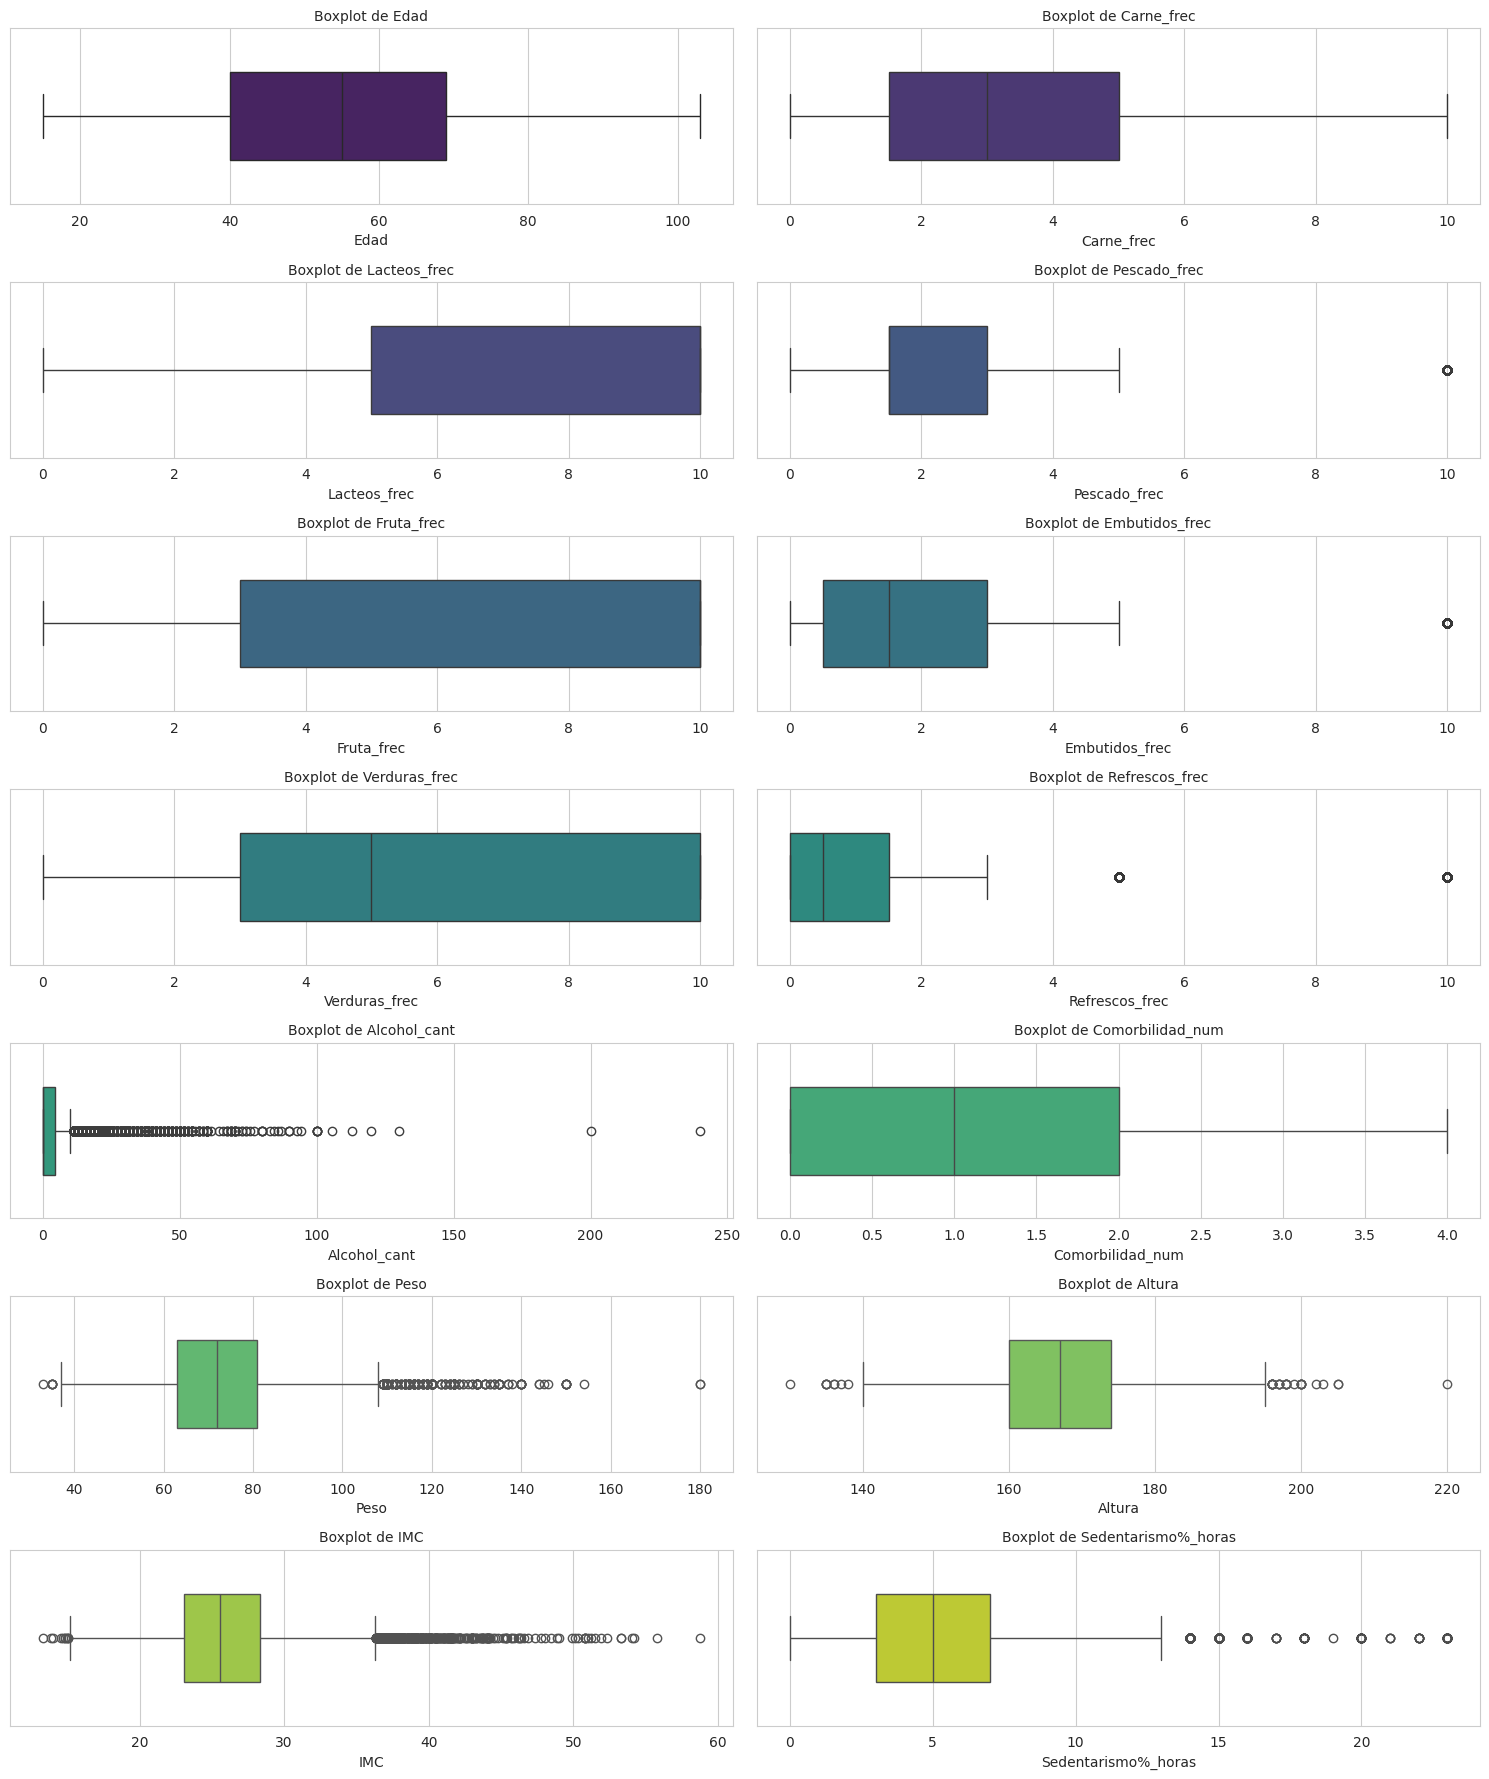

In [ ]:
# boxplots para las variables numericas que no son booleanas
plt.figure(figsize=(15,20))

colores= sns.color_palette('viridis',len(boxplot_cols.columns))

for i, col in enumerate(boxplot_cols):

  plt.subplot(8,2,i+1)
  sns.boxplot(x= boxplot_cols [col], color= colores[i], orient='h', width=0.5, linewidth=1)
  plt.title(f'Boxplot de {col}', fontsize=10)
  plt.xlabel(f'{col}', fontsize=10,)


plt.tight_layout()

plt.show()

# Análisis bivariante


In [ ]:
# Se revisa la distribución de la variable objetivo para obtener el porcentaje de cada categoría
print(tabulate(df_final["Salud_Percibida"].value_counts(normalize=True).to_frame(),headers='keys',tablefmt='psql'))

+-------------------+--------------+
| Salud_Percibida   |   proportion |
|-------------------+--------------|
| Bueno             |    0.485223  |
| Regular           |    0.241374  |
| Muy bueno         |    0.185599  |
| Malo              |    0.0701471 |
| Muy malo          |    0.0176557 |
+-------------------+--------------+


Se hace la compacion entre diferentes variables de enfermedades y la frecuencia de consumo de alimentos

In [ ]:
df_final.columns

Index(['Comunidad Autonoma', 'Sexo', 'Pais', 'Estudios', 'Clase', 'Edad',
       'Carne_frec', 'Lacteos_frec', 'Pescado_frec', 'Fruta_frec',
       'Embutidos_frec', 'Verduras_frec', 'Refrescos_frec', 'Alcohol_cant',
       'Salud_Percibida', 'Cronicidad_bin', 'Hipertension_bin', 'Diabetes_bin',
       'Colesterol_bin', 'Comorbilidad_num', 'Peso', 'Altura', 'IMC',
       'Actividad_física_cat', 'Sedentarismo%_horas', 'IMC_cat'],
      dtype='object')

In [ ]:
print(tabulate(df_final.groupby('Hipertension_bin')[var_frecuencia].mean().round(2),headers='keys',tablefmt='psql'))

+--------------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+
|   Hipertension_bin |   Carne_frec |   Lacteos_frec |   Pescado_frec |   Fruta_frec |   Embutidos_frec |   Verduras_frec |   Refrescos_frec |
|--------------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------|
|                  0 |         3.9  |           7.83 |           2.11 |         6.81 |             2.7  |            5.57 |             1.27 |
|                  1 |         3.68 |           8.1  |           2.27 |         7.54 |             2.39 |            5.98 |             0.77 |
+--------------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+


In [ ]:
print(tabulate(df_final.groupby('Diabetes_bin')[var_frecuencia].mean().round(2),headers='keys',tablefmt='psql'))

+----------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+
|   Diabetes_bin |   Carne_frec |   Lacteos_frec |   Pescado_frec |   Fruta_frec |   Embutidos_frec |   Verduras_frec |   Refrescos_frec |
|----------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------|
|              0 |         3.86 |           7.86 |           2.14 |         6.94 |             2.65 |            5.65 |             1.2  |
|              1 |         3.66 |           8.29 |           2.28 |         7.71 |             2.28 |            6.03 |             0.47 |
+----------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+


In [ ]:
print(tabulate(df_final.groupby('Colesterol_bin')[var_frecuencia].sum().round(2),headers='keys',tablefmt='psql'))

+------------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+
|   Colesterol_bin |   Carne_frec |   Lacteos_frec |   Pescado_frec |   Fruta_frec |   Embutidos_frec |   Verduras_frec |   Refrescos_frec |
|------------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------|
|                0 |      59496.5 |       119705   |        32415.5 |     104684   |          41070.5 |         85393.5 |            19085 |
|                1 |      19940   |        43885.5 |        12097.5 |      40499.5 |          12969.5 |         32269.5 |             4155 |
+------------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+


In [ ]:
print(tabulate(df_final.groupby('Actividad_física_cat')[var_enf].sum().round(2),headers='keys',tablefmt='psql'))

+------------------------+------------------+--------------------+----------------+------------------+
| Actividad_física_cat   |   Cronicidad_bin |   Hipertension_bin |   Diabetes_bin |   Colesterol_bin |
|------------------------+------------------+--------------------+----------------+------------------|
| Activo                 |             1634 |                528 |            136 |              591 |
| Ocasional              |             5577 |               2675 |            851 |             2421 |
| Regular                |             1201 |                383 |             87 |              417 |
| Sedentario             |             4666 |               2386 |            921 |             1941 |
+------------------------+------------------+--------------------+----------------+------------------+


In [ ]:
bivar_cols= ['Carne_frec', 'Lacteos_frec', 'Pescado_frec', 'Fruta_frec','Embutidos_frec', 'Verduras_frec', 'Refrescos_frec', 'Salud_Percibida',
       'Hipertension_bin', 'Diabetes_bin', 'Colesterol_bin','Comorbilidad_num', 'Actividad_física_cat', 'Pais', 'Sexo']
var_bivar = df_final[bivar_cols]
print(var_bivar.columns)

Index(['Carne_frec', 'Lacteos_frec', 'Pescado_frec', 'Fruta_frec',
       'Embutidos_frec', 'Verduras_frec', 'Refrescos_frec', 'Salud_Percibida',
       'Hipertension_bin', 'Diabetes_bin', 'Colesterol_bin',
       'Comorbilidad_num', 'Actividad_física_cat', 'Pais', 'Sexo'],
      dtype='object')


Por cada variable de frecuencia de alimentacin, se hace un analisis bivariante respecto a la presnecia de la variable 'Cronicidad' para revisar la presencia de alguna enfermedad crónica.


Tabla de distribución bivariada para: Carne_frec
+--------------+-------+-------+
|   Carne_frec |   0.0 |   1.0 |
|--------------+-------+-------|
|          0   |  0.39 |  0.61 |
|          0.5 |  0.3  |  0.7  |
|          1.5 |  0.34 |  0.66 |
|          3   |  0.36 |  0.64 |
|          5   |  0.38 |  0.62 |
|         10   |  0.39 |  0.61 |
+--------------+-------+-------+


<Figure size 600x400 with 0 Axes>

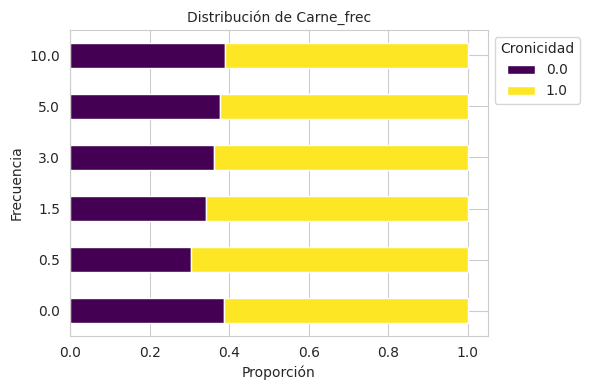


Tabla de distribución bivariada para: Lacteos_frec
+----------------+-------+-------+
|   Lacteos_frec |   0.0 |   1.0 |
|----------------+-------+-------|
|            0   |  0.32 |  0.68 |
|            0.5 |  0.34 |  0.66 |
|            1.5 |  0.38 |  0.62 |
|            3   |  0.42 |  0.58 |
|            5   |  0.41 |  0.59 |
|           10   |  0.35 |  0.65 |
+----------------+-------+-------+


<Figure size 600x400 with 0 Axes>

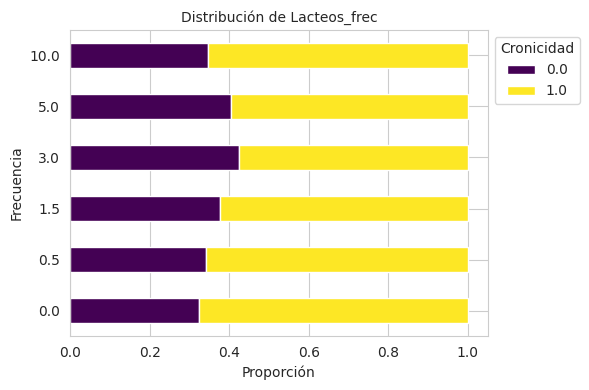


Tabla de distribución bivariada para: Pescado_frec
+----------------+-------+-------+
|   Pescado_frec |   0.0 |   1.0 |
|----------------+-------+-------|
|            0   |  0.38 |  0.62 |
|            0.5 |  0.42 |  0.58 |
|            1.5 |  0.36 |  0.64 |
|            3   |  0.36 |  0.64 |
|            5   |  0.32 |  0.68 |
|           10   |  0.36 |  0.64 |
+----------------+-------+-------+


<Figure size 600x400 with 0 Axes>

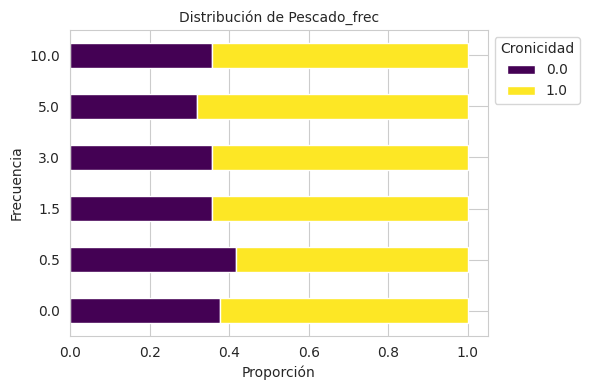


Tabla de distribución bivariada para: Fruta_frec
+--------------+-------+-------+
|   Fruta_frec |   0.0 |   1.0 |
|--------------+-------+-------|
|          0   |  0.36 |  0.64 |
|          0.5 |  0.42 |  0.58 |
|          1.5 |  0.4  |  0.6  |
|          3   |  0.41 |  0.59 |
|          5   |  0.4  |  0.6  |
|         10   |  0.33 |  0.67 |
+--------------+-------+-------+


<Figure size 600x400 with 0 Axes>

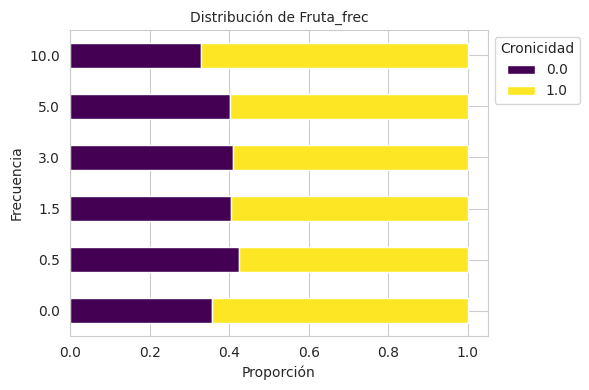


Tabla de distribución bivariada para: Embutidos_frec
+------------------+-------+-------+
|   Embutidos_frec |   0.0 |   1.0 |
|------------------+-------+-------|
|              0   |  0.32 |  0.68 |
|              0.5 |  0.28 |  0.72 |
|              1.5 |  0.36 |  0.64 |
|              3   |  0.4  |  0.6  |
|              5   |  0.41 |  0.59 |
|             10   |  0.42 |  0.58 |
+------------------+-------+-------+


<Figure size 600x400 with 0 Axes>

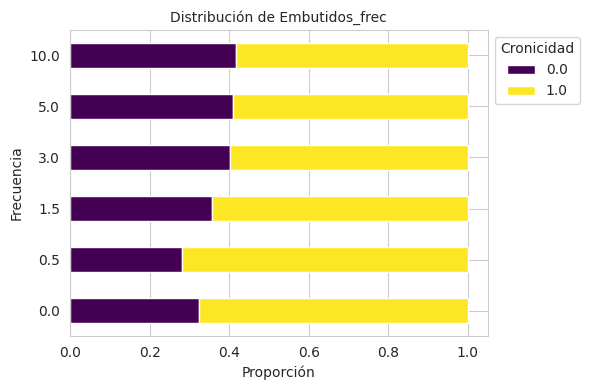


Tabla de distribución bivariada para: Verduras_frec
+-----------------+-------+-------+
|   Verduras_frec |   0.0 |   1.0 |
|-----------------+-------+-------|
|             0   |  0.43 |  0.57 |
|             0.5 |  0.41 |  0.59 |
|             1.5 |  0.43 |  0.57 |
|             3   |  0.4  |  0.6  |
|             5   |  0.36 |  0.64 |
|            10   |  0.31 |  0.69 |
+-----------------+-------+-------+


<Figure size 600x400 with 0 Axes>

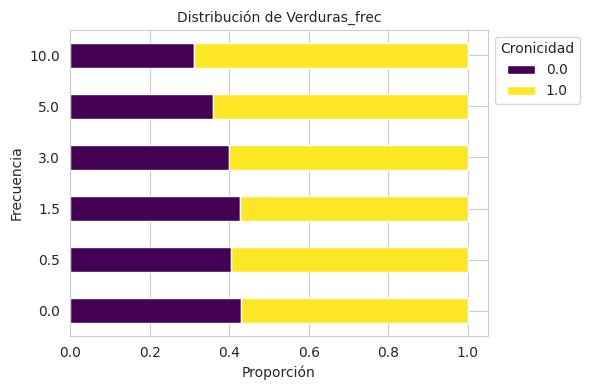


Tabla de distribución bivariada para: Refrescos_frec
+------------------+-------+-------+
|   Refrescos_frec |   0.0 |   1.0 |
|------------------+-------+-------|
|              0   |  0.26 |  0.74 |
|              0.5 |  0.4  |  0.6  |
|              1.5 |  0.51 |  0.49 |
|              3   |  0.47 |  0.53 |
|              5   |  0.5  |  0.5  |
|             10   |  0.41 |  0.59 |
+------------------+-------+-------+


<Figure size 600x400 with 0 Axes>

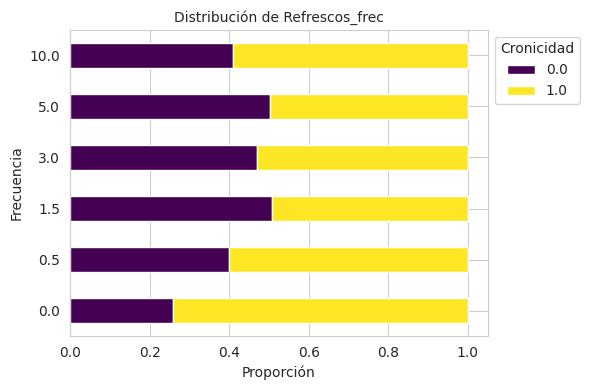


Tabla de distribución bivariada para: Salud_Percibida
+-------------------+-------+-------+
| Salud_Percibida   |   0.0 |   1.0 |
|-------------------+-------+-------|
| Bueno             |  0.42 |  0.58 |
| Malo              |  0.02 |  0.98 |
| Muy bueno         |  0.73 |  0.27 |
| Muy malo          |  0.01 |  0.99 |
| Regular           |  0.09 |  0.91 |
+-------------------+-------+-------+


<Figure size 600x400 with 0 Axes>

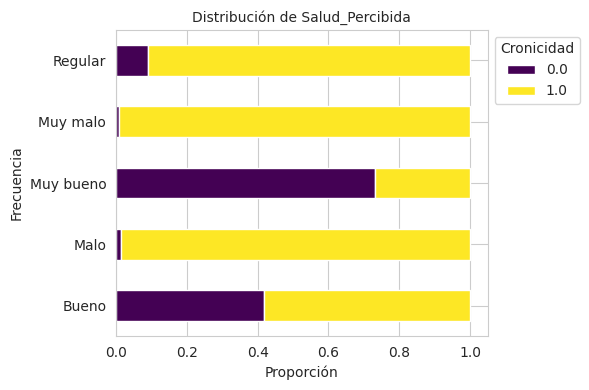


Tabla de distribución bivariada para: Hipertension_bin
+--------------------+-------+-------+
|   Hipertension_bin |   0.0 |   1.0 |
|--------------------+-------+-------|
|                  0 |  0.47 |  0.53 |
|                  1 |  0.1  |  0.9  |
+--------------------+-------+-------+


<Figure size 600x400 with 0 Axes>

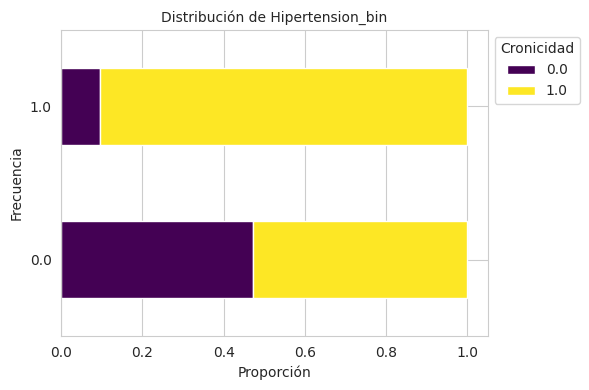


Tabla de distribución bivariada para: Diabetes_bin
+----------------+-------+-------+
|   Diabetes_bin |   0.0 |   1.0 |
|----------------+-------+-------|
|              0 |  0.4  |  0.6  |
|              1 |  0.05 |  0.95 |
+----------------+-------+-------+


<Figure size 600x400 with 0 Axes>

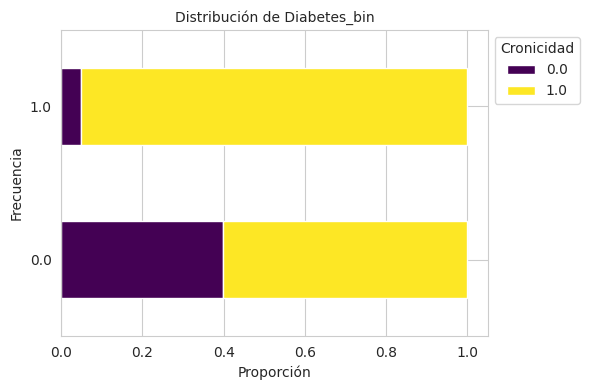


Tabla de distribución bivariada para: Colesterol_bin
+------------------+-------+-------+
|   Colesterol_bin |   0.0 |   1.0 |
|------------------+-------+-------|
|                0 |  0.45 |  0.55 |
|                1 |  0.12 |  0.88 |
+------------------+-------+-------+


<Figure size 600x400 with 0 Axes>

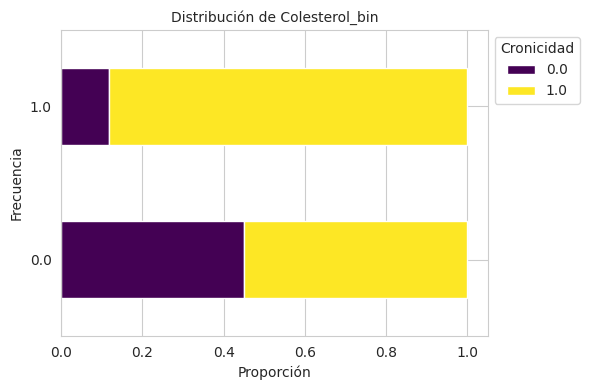


Tabla de distribución bivariada para: Comorbilidad_num
+--------------------+-------+-------+
|   Comorbilidad_num |   0.0 |   1.0 |
|--------------------+-------+-------|
|                  0 |  1    |  0    |
|                  1 |  0.13 |  0.87 |
|                  2 |  0.05 |  0.95 |
|                  3 |  0.01 |  0.99 |
|                  4 |  0    |  1    |
+--------------------+-------+-------+


<Figure size 600x400 with 0 Axes>

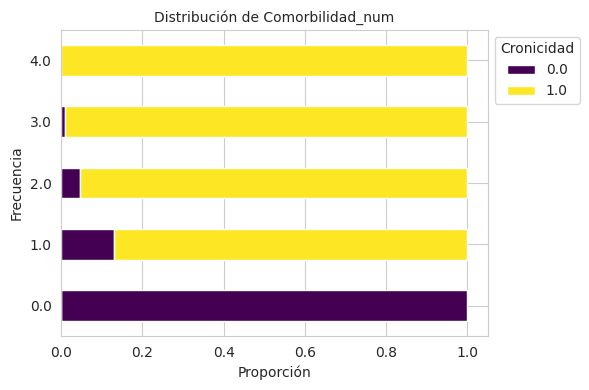


Tabla de distribución bivariada para: Actividad_física_cat
+------------------------+-------+-------+
| Actividad_física_cat   |   0.0 |   1.0 |
|------------------------+-------+-------|
| Activo                 |  0.48 |  0.52 |
| Ocasional              |  0.34 |  0.66 |
| Regular                |  0.51 |  0.49 |
| Sedentario             |  0.28 |  0.72 |
+------------------------+-------+-------+


<Figure size 600x400 with 0 Axes>

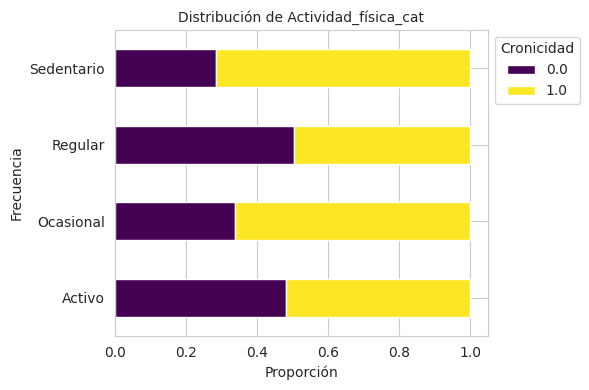


Tabla de distribución bivariada para: Pais
+--------------------------+-------+-------+
| Pais                     |   0.0 |   1.0 |
|--------------------------+-------+-------|
| Nacidos en España        |  0.34 |  0.66 |
| Nacidos en el extranjero |  0.51 |  0.49 |
+--------------------------+-------+-------+


<Figure size 600x400 with 0 Axes>

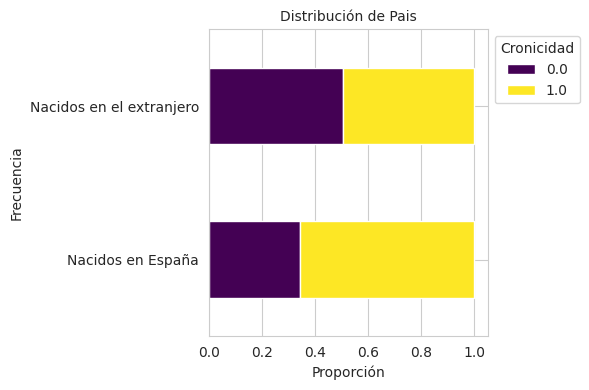


Tabla de distribución bivariada para: Sexo
+--------+-------+-------+
| Sexo   |   0.0 |   1.0 |
|--------+-------+-------|
| Hombre |  0.42 |  0.58 |
| Mujer  |  0.32 |  0.68 |
+--------+-------+-------+


<Figure size 600x400 with 0 Axes>

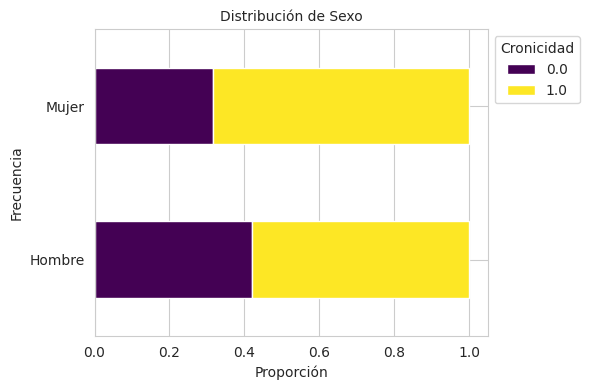

In [ ]:
# Referencia PEC
for col in var_bivar:

  tabla= pd.pivot_table(df_final,index=col,columns='Cronicidad_bin',aggfunc='size',fill_value=0)
  tabla_bivar= tabla.div(tabla.sum(axis=1), axis=0)
  print(f"\nTabla de distribución bivariada para: {col}")
  print(tabulate(tabla_bivar.round(2),headers='keys',tablefmt='psql'))

  plt.figure(figsize=(6,4))
  tabla_bivar.plot(kind='barh',stacked=True, figsize=(6,4), colormap="viridis")

  plt.title(f"Distribución de {col}", fontsize=10)
  plt.xlabel("Proporción", fontsize= 10)
  plt.ylabel("Frecuencia", fontsize= 10)
  plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Cronicidad')
  plt.tight_layout()
  plt.show()

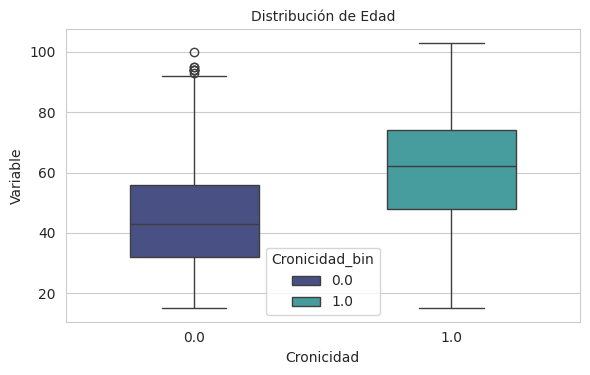

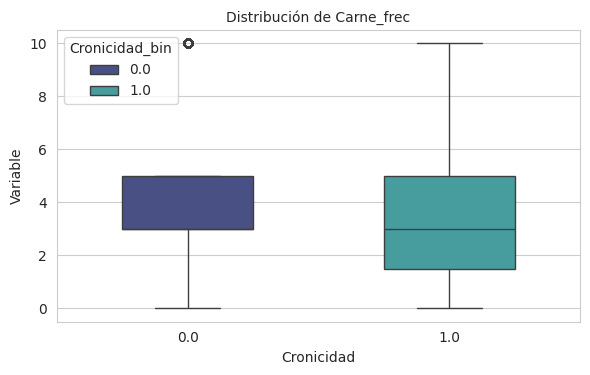

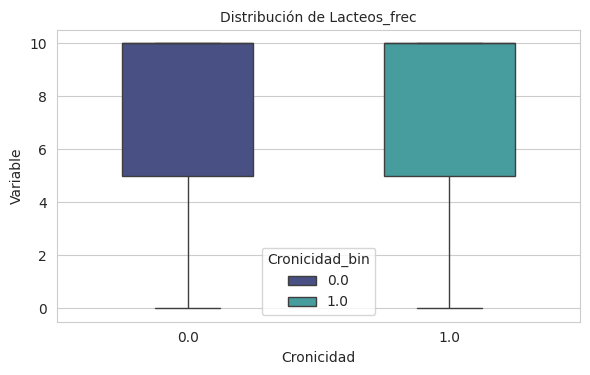

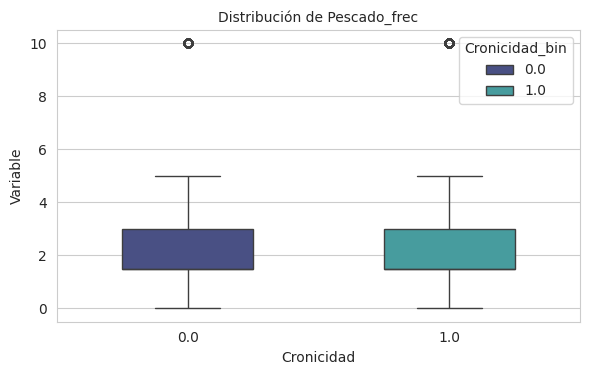

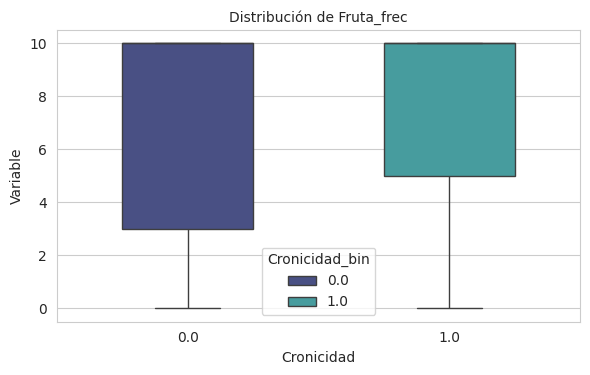

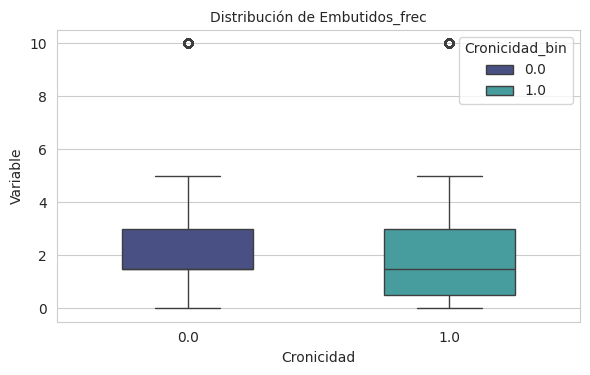

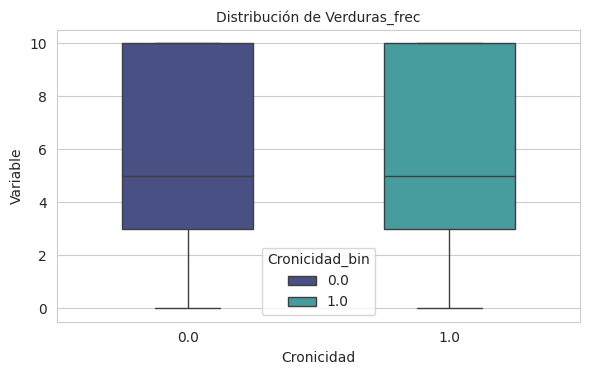

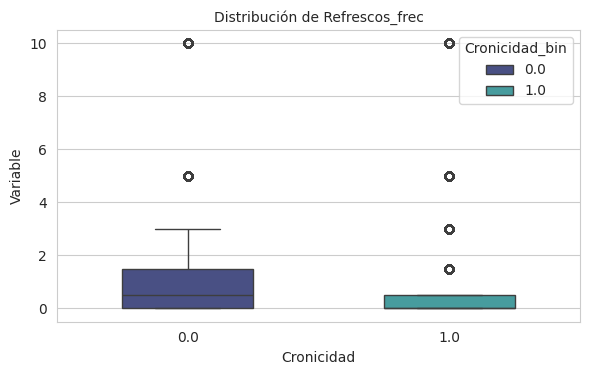

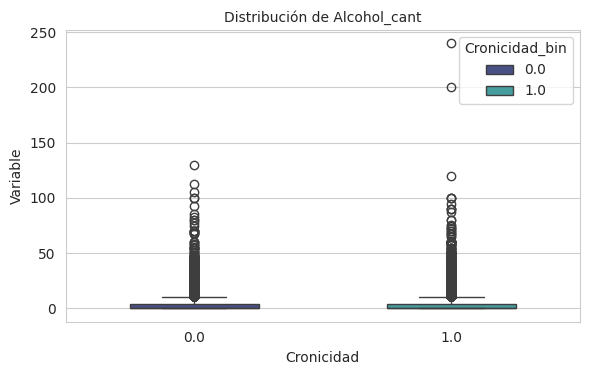

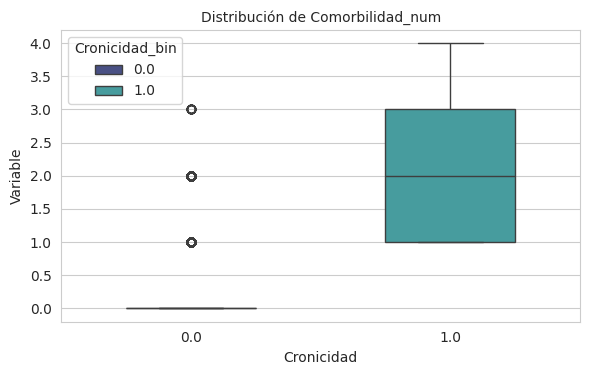

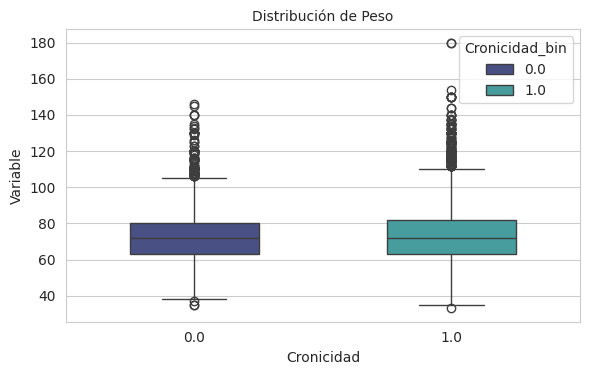

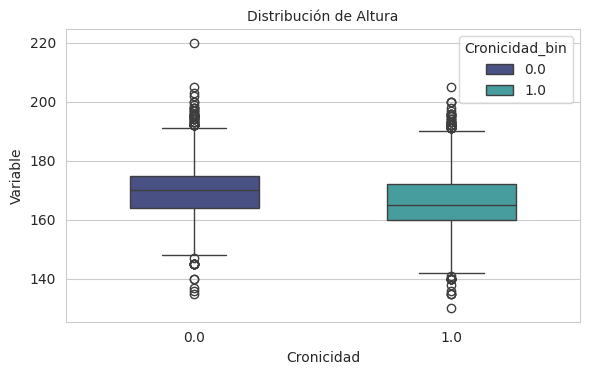

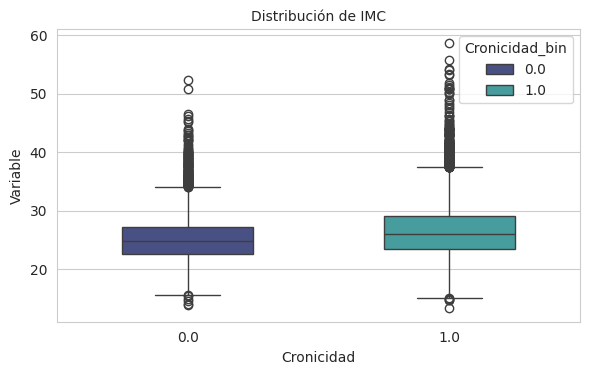

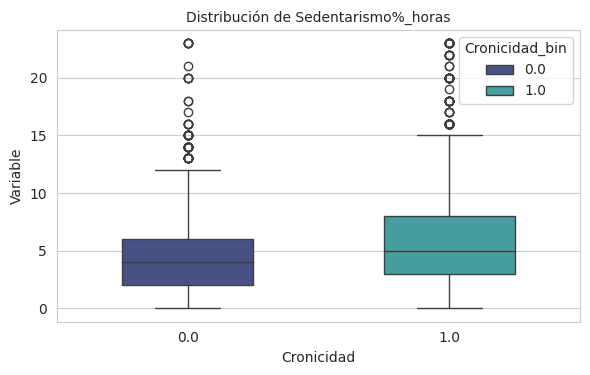

In [ ]:
for col in boxplot_cols:


  tabla_num= df_final.dropna(subset=[col,'Cronicidad_bin'])

  plt.figure(figsize=(6,4))
  sns.boxplot(data=tabla_num, x='Cronicidad_bin', y=col, palette="mako", width=0.5, linewidth=1, hue='Cronicidad_bin')
  plt.title(f"Distribución de {col}", fontsize=10)
  plt.suptitle('')
  plt.xlabel("Cronicidad")
  plt.ylabel("Variable")
  plt.tight_layout()
  plt.show()